In [17]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.data_loader import load_data
from src.data_cleaning import clean_data
from src.data_preparation import prepare_data

df = load_data()
df = clean_data(df)
df = prepare_data(df)

# Monthly sales
df.groupby('month')['total_value'].sum()

c:\myProjects\IntrenShipStudioProject\src\data_loader.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


month
1     724107.0
2     645114.0
3     636502.0
4     515791.0
5     633212.0
6     697014.0
7     717207.0
8     726921.0
9     694366.0
10    725272.0
11    698273.0
12    709894.0
Name: total_value, dtype: float64

In [18]:
df = load_data()
df = clean_data(df)
df = prepare_data(df)

print("\n📊 Basic KPIs:")

print(f"Total records: {len(df):,}")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Total revenue: ₹{df['total_value'].sum():,.2f}")
print(f"Average transaction value: ₹{df['total_value'].mean():,.2f}")

c:\myProjects\IntrenShipStudioProject\src\data_loader.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)



📊 Basic KPIs:
Total records: 124,994
Unique customers: 6,889
Total revenue: ₹8,123,673.00
Average transaction value: ₹64.99


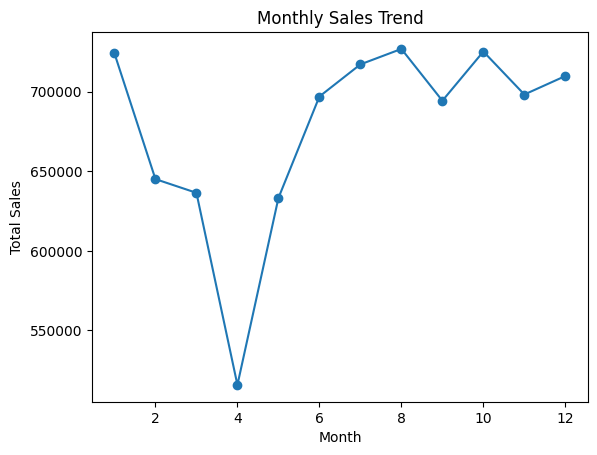

In [22]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [23]:
top_customers = df.groupby('customer_id')['total_value'].sum().sort_values(ascending=False).head(10)
print(top_customers)

customer_id
CS4424    2933.0
CS4320    2647.0
CS5752    2612.0
CS4660    2527.0
CS3799    2513.0
CS5109    2506.0
CS4074    2462.0
CS3805    2453.0
CS4608    2449.0
CS5555    2439.0
Name: total_value, dtype: float64


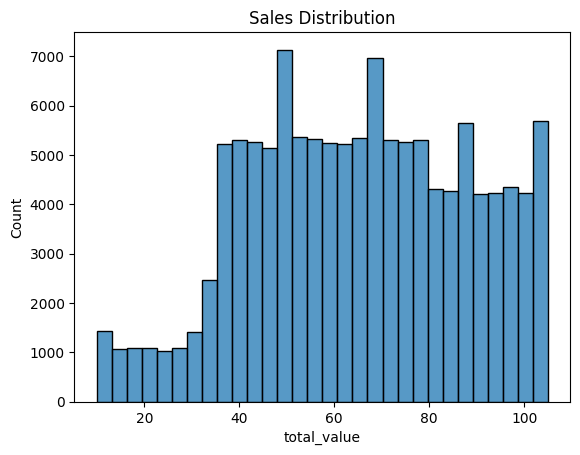

In [24]:
import seaborn as sns

sns.histplot(df['total_value'], bins=30)
plt.title("Sales Distribution")
plt.show()

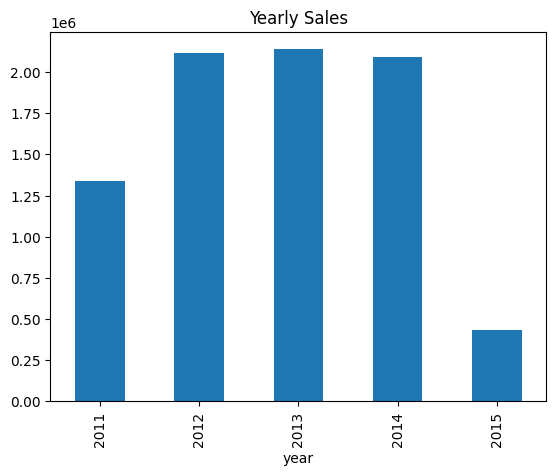

In [25]:
df.groupby('year')['total_value'].sum().plot(kind='bar')
plt.title("Yearly Sales")
plt.show()

In [26]:
df['first_purchase'] = df.groupby('customer_id')['trans_date'].transform('min')

df['cohort'] = df['first_purchase'].dt.to_period('M')
df['order_month'] = df['trans_date'].dt.to_period('M')

cohort_data = df.groupby(['cohort', 'order_month']).size().unstack(fill_value=0)
print(cohort_data)

order_month  2011-05  2011-06  2011-07  2011-08  2011-09  2011-10  2011-11  \
cohort                                                                       
2011-05         1485      517      567      578      531      607      496   
2011-06            0     2190      707      763      702      751      673   
2011-07            0        0     1452      512      497      552      483   
2011-08            0        0        0     1061      325      325      315   
2011-09            0        0        0        0      550      147      165   
2011-10            0        0        0        0        0      456      152   
2011-11            0        0        0        0        0        0      286   
2011-12            0        0        0        0        0        0        0   
2012-01            0        0        0        0        0        0        0   
2012-02            0        0        0        0        0        0        0   
2012-03            0        0        0        0        0        

In [27]:
df['total_value'].mean()

np.float64(64.99250364017473)